# Week 6: Propaganda Detection

This week we will be looking at the propaganda detection task (Da San Martino 2019) and developing a baseline model for technique classification.

We will be working with an adapted version of the dataset from the paper.  In particular, I have
* reduced the number of propaganda techniques
* randomly sampled sentences labelled with a particular technique
* randomly sampled sentences (from the same original articles) which do not contain propaganda
* reformatted the data so that the snippets can be "read" in the context of the sentence by inserting \<BOS\> and \<EOS\> tags.

Let's load it up in a pandas dataframe so that we can look at some examples to illustrate that last point.

In [1]:
import os
parentdir = "data"
train_file= "propaganda_train.tsv"
train_path=os.path.join(parentdir,train_file)


In [2]:
import pandas as pd
train_df=pd.read_csv(train_path,delimiter="\t",quotechar='|')
train_df.head(20)

,label,tagged_in_context
0,not_propaganda,"No, <BOS> he <EOS> will not be confirmed."
1,not_propaganda,This declassification effort <BOS> won’t make ...
2,flag_waving,"""The Obama administration misled the <BOS> Ame..."
3,not_propaganda,“It looks like we’re capturing the demise of t...
4,not_propaganda,"<BOS> Location: Westerville, Ohio <EOS>"
5,loaded_language,"Hitler <BOS> annihilated <EOS> 400,000 Germans..."
6,not_propaganda,A federal judge on Monday ordered U.S. immigra...
7,not_propaganda,<BOS> Kirstjen Nielsen (@SecNielsen) <EOS> Nov...
8,doubt,"As noted above, at this point literally every ..."
9,not_propaganda,Britain doesn't need more hate even just for a...


We can see in the cell above that there are 2 columns.  The first column is the label i.e., the propaganda technique or the label "not_propaganda".  The 2nd column contains the text.  Within the text we can see the special \<BOS\> and \<EOS\> tags which indicate the propaganda snippet.

Let's have a look at some examples from the **loaded_language** class.

In [3]:
train_df[train_df["label"]=="loaded_language"]

,label,tagged_in_context
5,loaded_language,"Hitler <BOS> annihilated <EOS> 400,000 Germans..."
21,loaded_language,We’ve caught on to his <BOS> sneaky <EOS> syno...
49,loaded_language,This is why it is so <BOS> heinous <EOS>.”
106,loaded_language,Here is the <BOS> dirty <EOS> secret that is n...
124,loaded_language,She offered no evidence — nor was asked for an...
...,...,...
2447,loaded_language,The ADL described the video as “<BOS> venomous...
2458,loaded_language,What started after the 2016 election as a redu...
2487,loaded_language,Its superior had made the <BOS> fatal <EOS> er...
2496,loaded_language,Ridicule is a <BOS> vicious and potent <EOS> w...


In the first loaded_language example (row 5 of the original dataframe), we can see that there is a single word *annihilated* which is between \<BOS\> (**beginning of span**) and \<EOS\> (**end of span**).

## Exercise 1: Exploratory Data Analysis
Write code and plot appropriate graphs to visualise each of the following questions.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### a) How many samples are there for each class?

In [5]:
label_classes = train_df["label"].value_counts().to_dict()
label_classes

{'not_propaganda': 1269,
 'exaggeration,minimisation': 170,
 'name_calling,labeling': 166,
 'causal_oversimplification': 165,
 'loaded_language': 161,
 'repetition': 160,
 'doubt': 157,
 'appeal_to_fear_prejudice': 157,
 'flag_waving': 155}

Text(0, 0.5, 'Counts')

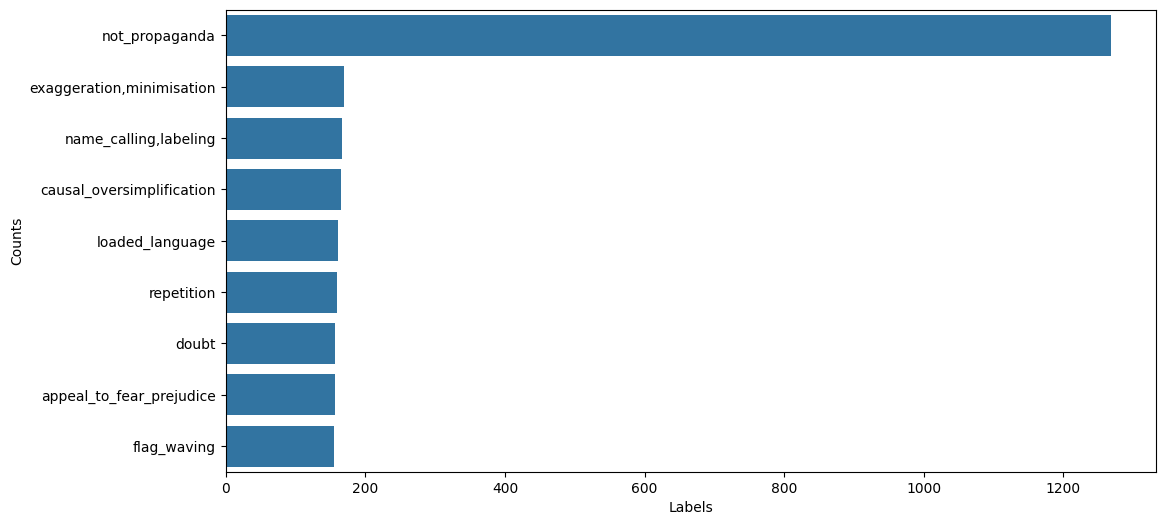

In [6]:
plt.figure(figsize=(12,6))
sns.barplot(label_classes, orient="y")
plt.xlabel("Labels")
plt.ylabel("Counts")

### b) What is the average length of sentence for each class?

In [7]:
avg_length_sent = {}
for tech in list(label_classes.keys()):
    filter = train_df["label"] == tech
    filtered = train_df.loc[filter]["tagged_in_context"]

    avg_length = len(filtered.sum())/  int(filtered.count())
    avg_length_sent[tech] = avg_length
    print(f"Average length of sentence in {tech} : {avg_length}")

Average length of sentence in not_propaganda : 137.90858944050433
Average length of sentence in exaggeration,minimisation : 197.38235294117646
Average length of sentence in name_calling,labeling : 214.42168674698794
Average length of sentence in causal_oversimplification : 208.5939393939394
Average length of sentence in loaded_language : 179.69565217391303
Average length of sentence in repetition : 160.35
Average length of sentence in doubt : 199.0
Average length of sentence in appeal_to_fear_prejudice : 184.98089171974522
Average length of sentence in flag_waving : 192.23225806451612


Text(0, 0.5, 'Counts')

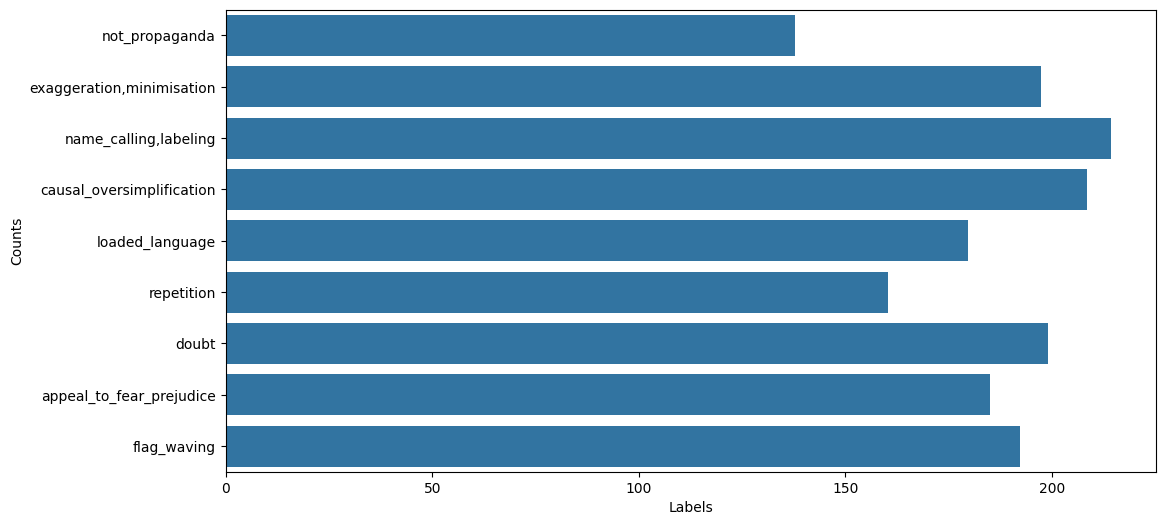

In [8]:
plt.figure(figsize=(12,6))
sns.barplot(avg_length_sent, orient="y")
plt.xlabel("Labels")
plt.ylabel("Counts")

### c) What is the average length of propaganda snippet for each class? 

In [9]:
filter = train_df["label"] == 'loaded_language'
filtered = train_df.loc[filter]["tagged_in_context"]
filtered

5       Hitler <BOS> annihilated <EOS> 400,000 Germans...
21      We’ve caught on to his <BOS> sneaky <EOS> syno...
49            This is why it is so <BOS> heinous <EOS>.” 
106     Here is the <BOS> dirty <EOS> secret that is n...
124     She offered no evidence — nor was asked for an...
                              ...                        
2447    The ADL described the video as “<BOS> venomous...
2458    What started after the 2016 election as a redu...
2487    Its superior had made the <BOS> fatal <EOS> er...
2496    Ridicule is a <BOS> vicious and potent <EOS> w...
2519    But this move demonstrates—if more evidence we...
Name: tagged_in_context, Length: 161, dtype: str

In [10]:
avg_length_span = {}
all_spans = []
for tech in list(label_classes.keys()):
    filter = train_df["label"] == tech
    filtered = train_df.loc[filter]["tagged_in_context"]
    
    for sent in filtered:
        sent = sent.strip().split(" ")
        
        
        BEGIN_TOKEN = '<BOS>'
        END_TOKEN = '<EOS>'
        ids_start = 0
        ids_end = 0
        for i, token in enumerate(sent):

        
            if BEGIN_TOKEN in token:
                ids_start = i+1
                continue

            if END_TOKEN in token:
                ids_end = i
                
        all_spans.append(sent[ids_start : ids_end])   
    
    span = [span for spans in all_spans for span in spans]
 
    avg_length_span[tech] = len(span) / len(all_spans)

avg_length_span

{'not_propaganda': 6.441292356185973,
 'exaggeration,minimisation': 6.590687977762335,
 'name_calling,labeling': 6.353271028037383,
 'causal_oversimplification': 7.757627118644068,
 'loaded_language': 7.402382185396168,
 'repetition': 7.054997608799617,
 'doubt': 8.002224199288257,
 'appeal_to_fear_prejudice': 8.634927234927234,
 'flag_waving': 8.762109375}

Text(0, 0.5, 'Counts')

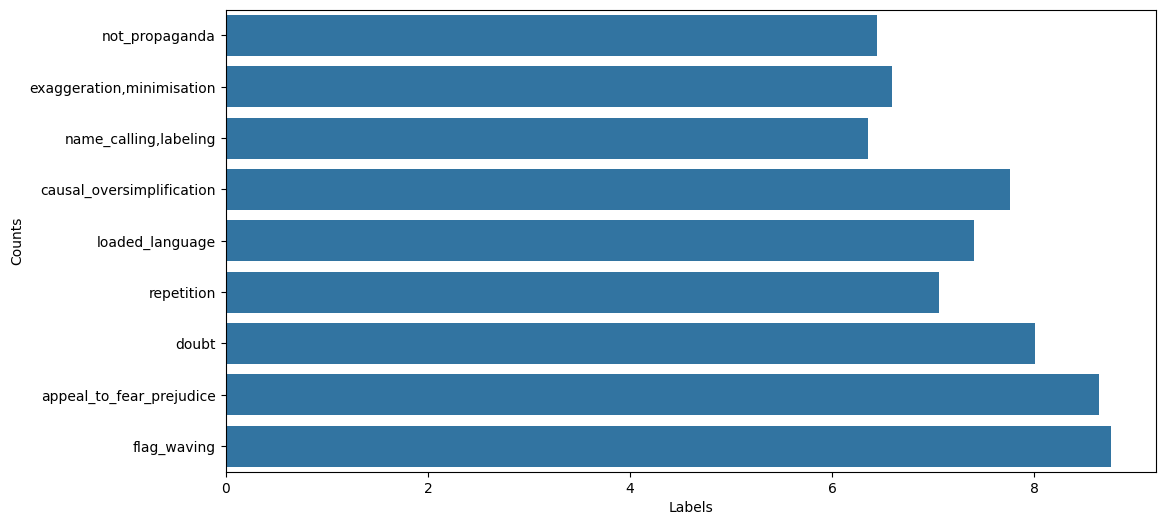

In [11]:
plt.figure(figsize=(12,6))
sns.barplot(avg_length_span, orient="y")
plt.xlabel("Labels")
plt.ylabel("Counts")

## Exercise 2: Sentence Level Binary classification

Build a simple classifier (e.g., Naïve Bayes or Logistic Regression) which can take a sentence and predict whether it contains propaganda or not.  


Things you will need to think about

* making a binary "propaganda" or "not_propaganda" label
* splitting the data into training and validation
* making a bag-of-words representation of each sentence.  This could be a dictionary where the keys are the words and the values are the frequencies within the sentence.  
* the implementation of the classifier itself.  You are not expected to build this yourself.  A good one to use would be the multinomialNB classifier in scikit-learn

It's worth thinking about the input format expected by the classifier before pre-processing the data.  Code to import and use the scikit-learn multinomialNB classifier is below for consideration

In [12]:
#This gives us some random toy data.  
#In this toy data there are 10 data points (e.g., sentences) 
# each sentence is represented as a vector of 100 values
# each value could be the frequency of a particular word in the vocab.  The max frequency here is 6
# these are stored in X
# there are 2 possible labels (0 and 1) which are stored in Y

import numpy as np
rng=np.random.RandomState()
X = rng.randint(6,size=(10,100))
Y = rng.randint(2, size=10)

print(X)
print(Y)

[[2 3 4 4 4 0 4 1 4 2 5 0 5 5 0 2 4 5 2 0 3 1 3 3 0 1 5 0 3 3 4 1 5 2 1 3
  5 2 3 1 5 4 3 4 5 4 2 1 4 0 2 0 3 0 0 1 0 1 3 4 4 5 3 1 0 3 1 1 5 3 5 4
  3 0 1 5 4 5 3 0 4 5 4 1 3 3 0 0 2 1 0 2 4 5 2 5 2 5 3 2]
 [3 3 3 4 3 2 3 2 4 5 0 2 2 5 5 5 1 4 5 1 4 4 5 0 5 3 2 2 0 3 0 4 1 4 3 5
  5 5 3 3 2 0 4 1 3 5 1 4 3 2 2 1 3 0 3 0 1 0 3 1 4 3 4 3 5 1 4 1 4 1 4 1
  3 5 5 4 3 1 5 0 3 3 1 0 5 1 0 0 0 3 2 0 0 0 3 2 2 0 3 1]
 [4 4 4 5 2 0 2 2 3 0 2 3 4 0 5 3 1 1 4 3 0 4 4 2 5 0 5 4 3 2 5 1 2 2 1 5
  2 5 0 4 2 5 2 1 3 3 2 1 4 4 4 2 5 3 5 1 5 1 5 0 3 0 2 2 1 3 0 2 0 2 5 3
  1 3 5 0 3 1 2 3 2 5 2 0 3 0 3 4 3 4 2 4 0 4 5 3 2 3 3 5]
 [1 3 5 1 0 4 0 3 3 4 1 3 1 1 4 5 3 1 2 0 2 2 4 2 2 2 2 1 3 0 1 1 2 0 5 5
  4 5 4 3 3 5 1 5 3 4 2 2 3 5 2 0 2 4 1 1 5 5 4 0 3 4 1 1 4 1 3 4 0 5 4 4
  5 3 3 0 0 0 0 1 5 0 5 2 0 1 2 5 2 2 5 1 3 0 1 1 0 4 3 3]
 [3 2 1 5 3 2 3 0 2 5 2 2 3 0 4 3 1 3 5 0 5 0 0 0 3 0 4 3 1 4 4 1 2 4 0 3
  5 2 5 3 2 3 0 5 2 2 0 4 4 5 4 4 2 2 4 2 4 5 0 3 5 3 4 0 1 4 5 0 4 5 3 2
  5 3 1 5 1 5 1 1 2 0 2 

In [13]:
train_df["tagged_in_context"] = train_df["tagged_in_context"].str.strip()

In [14]:
train_df.loc[0, "tagged_in_context"]

'No, <BOS> he <EOS> will not be confirmed.'

In [15]:
filter_not = train_df["label"] == "not_propaganda"
not_propaganda_sentences = train_df.loc[filter_not]

filter_is = train_df["label"] != "not_propaganda"
propaganda_sentences = train_df.loc[filter_is]
propaganda_sentences["label"] = "propaganda"

print(train_df["label"].value_counts())
print(not_propaganda_sentences)
print(propaganda_sentences)

label
not_propaganda               1269
exaggeration,minimisation     170
name_calling,labeling         166
causal_oversimplification     165
loaded_language               161
repetition                    160
doubt                         157
appeal_to_fear_prejudice      157
flag_waving                   155
Name: count, dtype: int64
               label                                  tagged_in_context
0     not_propaganda          No, <BOS> he <EOS> will not be confirmed.
1     not_propaganda  This declassification effort <BOS> won’t make ...
3     not_propaganda  “It looks like we’re capturing the demise of t...
4     not_propaganda            <BOS> Location: Westerville, Ohio <EOS>
6     not_propaganda  A federal judge on Monday ordered U.S. immigra...
...              ...                                                ...
2554  not_propaganda  Now how <BOS> does Farage propose to do <EOS> ...
2555  not_propaganda  <BOS> We support and appreciate <EOS> your bus...
2556  not_prop

In [18]:
main_df = pd.concat([propaganda_sentences, not_propaganda_sentences])


In [19]:
main_df["tagged_in_context"]

2       "The Obama administration misled the <BOS> Ame...
5       Hitler <BOS> annihilated <EOS> 400,000 Germans...
8       As noted above, at this point literally every ...
10      His account was suspended for violating Twitte...
12      A couple of seemingly unrelated events this pa...
                              ...                        
2554    Now how <BOS> does Farage propose to do <EOS> ...
2555    <BOS> We support and appreciate <EOS> your bus...
2556    International Atomic Energy Agency (IAEA) Dire...
2557    What has been done: there has been work on for...
2558    This is <BOS> the law of gradualness not the g...
Name: tagged_in_context, Length: 2560, dtype: str

In [20]:
main_df.loc[0,"tagged_in_context"]

'No, <BOS> he <EOS> will not be confirmed.'

In [21]:
main_df["label"].value_counts()

label
propaganda        1291
not_propaganda    1269
Name: count, dtype: int64

In [22]:
sentence_level = []

for label, sent in main_df.itertuples(index=False):

    if label == "not_propaganda":
        sentence_level.append((sent, 0))

    if label == "propaganda":
        sentence_level.append((sent, 1))
sentence_level[:5]

[('"The Obama administration misled the <BOS> American people <EOS> and Congress because they were desperate to get a deal with Iran," said Sen.',
  1),
 ('Hitler <BOS> annihilated <EOS> 400,000 Germans who were handicapped or suffered from chronic diseases.',
  1),
 ('As noted above, at this point literally every piece of <BOS> so-called evidence <EOS> put forth by authorities and then regurgitated by the mainstream media cannot be trusted and should be considered as disinformation until proven otherwise.',
  1),
 ('His account was suspended for violating Twitter’s rules relating to “<BOS> hateful conduct <EOS>.” It is "hateful conduct", apparently, to reference what Islamic texts themselves say.',
  1),
 ('A couple of seemingly unrelated events this past week <BOS> point to Iran’s positioning itself for more aggressive military actions that could place U.S. forces in harm’s way <EOS>.',
  1)]

In [23]:
beg_tokens = []
end_tokens = []
for _, sent in main_df.itertuples(index=False):
    sent = sent.split(" ")

    for token in sent:
        if BEGIN_TOKEN in token:
            if token != BEGIN_TOKEN:
                beg_tokens.append(token)

        if END_TOKEN in token:
            if token != END_TOKEN:
                end_tokens.append(token)

In [24]:
print(set(beg_tokens))
print(set(end_tokens))

{'‘<BOS>', 'conservatives…<BOS>', '“[<BOS>', '[<BOS>', 'Schools.”<BOS>', 'heart—<BOS>', '“(<BOS>', 'Tuesday,“<BOS>', '"<BOS>', '“<BOS>', '#<BOS>', '––<BOS>'}
{'<EOS>…', '<EOS>”:', '<EOS>",', '<EOS>."', '<EOS>!', '<EOS>,"', '<EOS>.’”', '<EOS>1]”', '<EOS>).', '<EOS>--they,', '<EOS>;', '<EOS>"', '<EOS>,’', '<EOS>!”', '<EOS>,’”', '<EOS>”]', '<EOS>!’', '<EOS>”.', '<EOS>".', '<EOS>.’', "<EOS>,'”", '<EOS>….We', '<EOS>”—like', '<EOS>”', '<EOS>.', '<EOS>—with', '<EOS>”;', '<EOS>...Boy,', '<EOS>ded', '<EOS>,', '<EOS>,”', '<EOS>including', '<EOS>’', '<EOS>!!!', '<EOS>s', '<EOS>?”', '<EOS>?', '<EOS>),', '<EOS>].”', '<EOS>.”', '<EOS>:', '<EOS>….', "<EOS>'s", '<EOS>…”', '<EOS>’s'}


In [25]:
import spacy
nlp = spacy.load("en_core_web_sm")
nlp.tokenizer.add_special_case("<BOS>", [{"ORTH": "<BOS>"}])
nlp.tokenizer.add_special_case("<EOS>", [{"ORTH": "<EOS>"}])

In [26]:
all_sentences = []
for label, sent in main_df.itertuples(index=False):

    if label == "not_propaganda":
        sent = sent.replace("<BOS>", " <BOS> ")
        sent = sent.replace("<EOS>", " <EOS> ")
        all_sentences.append(([token.text for token in nlp(sent) if not token.is_space], 0))

    if label == "propaganda":
        sent = sent.replace("<BOS>", " <BOS> ")
        sent = sent.replace("<EOS>", " <EOS> ")
        all_sentences.append(([token.text for token in nlp(sent) if not token.is_space], 1))


count = 0

for sent in all_sentences:

    sen, label = sent
        
    if label == 1:
        count += 1
print(count)


1291


In [27]:
import random
def split_create(data, split=0.6):

    random.seed(43)
    random.shuffle(data)
    n = len(data)
    idx = int(n*split)
    test_idx = int((n-idx) / 2)
    return data[:idx], data[idx: -test_idx], data[-test_idx:] 

In [28]:
train_sent_set, val_sent_set, test_sent_set = split_create(sentence_level)

print(*train_sent_set[:5], sep="\n")
print(len(train_sent_set))
print("-" *50)
print(*val_sent_set[:5], sep="\n")
print(len(val_sent_set))
print("-" *50)
print(*val_sent_set[:5], sep="\n")
print(len(val_sent_set))

('Perry noted that <BOS> all Americans <EOS> are still lacking all the evidence.', 1)
('Will none of the hierarchs rise to defend the Church as “a new <BOS> Athanasius, <EOS> a new Basil”?', 0)
('Authentic autonomy, independence of formation and <BOS> finances, “are essential points of our charism that Our Holy Mother established and to do away with them is to do <EOS> away with the charism.”', 0)
('And the decision to act upon this disordered inclination is <BOS> a sin so grave that it cries out to heaven for vengeance <EOS>, especially when it involves preying upon the young or the vulnerable.', 1)
('Haig plans to hold a news conference Friday to discuss his interaction with <BOS> Paddock. <EOS>', 0)
1536
--------------------------------------------------
("[Editors' note: To best understand why Facebook would ban Jamie Glazov on 9/11 for his article on how to best prevent more 9/11s, pre-order Jamie's new book, Jihadist Psychopath: How He Is <BOS> Charming, Seducing, and Devouring U

In [29]:
train_set, val_set, test_set = split_create(all_sentences)

print(*train_set[:5], sep="\n")
print(len(train_set))
print("-" *50)
print(*val_set[:5], sep="\n")
print(len(val_set))
print("-" *50)
print(*test_set[:5], sep="\n")
print(len(test_set))

(['Perry', 'noted', 'that', '<BOS>', 'all', 'Americans', '<EOS>', 'are', 'still', 'lacking', 'all', 'the', 'evidence', '.'], 1)
(['Will', 'none', 'of', 'the', 'hierarchs', 'rise', 'to', 'defend', 'the', 'Church', 'as', '“', 'a', 'new', '<BOS>', 'Athanasius', ',', '<EOS>', 'a', 'new', 'Basil', '”', '?'], 0)
(['Authentic', 'autonomy', ',', 'independence', 'of', 'formation', 'and', '<BOS>', 'finances', ',', '“', 'are', 'essential', 'points', 'of', 'our', 'charism', 'that', 'Our', 'Holy', 'Mother', 'established', 'and', 'to', 'do', 'away', 'with', 'them', 'is', 'to', 'do', '<EOS>', 'away', 'with', 'the', 'charism', '.', '”'], 0)
(['And', 'the', 'decision', 'to', 'act', 'upon', 'this', 'disordered', 'inclination', 'is', '<BOS>', 'a', 'sin', 'so', 'grave', 'that', 'it', 'cries', 'out', 'to', 'heaven', 'for', 'vengeance', '<EOS>', ',', 'especially', 'when', 'it', 'involves', 'preying', 'upon', 'the', 'young', 'or', 'the', 'vulnerable', '.'], 1)
(['Haig', 'plans', 'to', 'hold', 'a', 'news', 'c

In [30]:
from nltk.probability import FreqDist
import string

def create_bow(data):


    clean_tokens = [token for sent, _ in train_set for token in sent 
                    if token not in [BEGIN_TOKEN, END_TOKEN] and not token.isspace()]

    created_bow = FreqDist(clean_tokens)

    return created_bow



In [31]:
train_bow = create_bow(train_set)
val_bow = create_bow(val_set)
test_bow = create_bow(test_set)

In [32]:
train_bow 

FreqDist({'the': 2401, ',': 2010, '.': 1420, 'to': 1233, 'of': 1191, 'and': 984, 'in': 706, 'a': 689, 'that': 642, '”': 462, ...})

In [33]:
train_set

[(['Perry',
   'noted',
   'that',
   '<BOS>',
   'all',
   'Americans',
   '<EOS>',
   'are',
   'still',
   'lacking',
   'all',
   'the',
   'evidence',
   '.'],
  1),
 (['Will',
   'none',
   'of',
   'the',
   'hierarchs',
   'rise',
   'to',
   'defend',
   'the',
   'Church',
   'as',
   '“',
   'a',
   'new',
   '<BOS>',
   'Athanasius',
   ',',
   '<EOS>',
   'a',
   'new',
   'Basil',
   '”',
   '?'],
  0),
 (['Authentic',
   'autonomy',
   ',',
   'independence',
   'of',
   'formation',
   'and',
   '<BOS>',
   'finances',
   ',',
   '“',
   'are',
   'essential',
   'points',
   'of',
   'our',
   'charism',
   'that',
   'Our',
   'Holy',
   'Mother',
   'established',
   'and',
   'to',
   'do',
   'away',
   'with',
   'them',
   'is',
   'to',
   'do',
   '<EOS>',
   'away',
   'with',
   'the',
   'charism',
   '.',
   '”'],
  0),
 (['And',
   'the',
   'decision',
   'to',
   'act',
   'upon',
   'this',
   'disordered',
   'inclination',
   'is',
   '<BOS>',
   'a',

In [34]:
def to_feat_label(data, bow):

    comp_data = []

    for sent, label in data:
        
        sents = {}
        for token in sent:

            if token in [BEGIN_TOKEN, END_TOKEN]:
                continue
            
            sents[token] = bow[token]
        comp_data.append((sents, label))

    return comp_data

In [35]:
train_data = to_feat_label(train_set, train_bow)
val_data = to_feat_label(val_set, val_bow)
test_data = to_feat_label(test_set, test_bow)

In [36]:
train_data

[({'Perry': 5,
   'noted': 7,
   'that': 642,
   'all': 99,
   'Americans': 16,
   'are': 220,
   'still': 29,
   'lacking': 2,
   'the': 2401,
   'evidence': 17,
   '.': 1420},
  1),
 ({'Will': 7,
   'none': 2,
   'of': 1191,
   'the': 2401,
   'hierarchs': 3,
   'rise': 9,
   'to': 1233,
   'defend': 10,
   'Church': 88,
   'as': 224,
   '“': 442,
   'a': 689,
   'new': 30,
   'Athanasius': 4,
   ',': 2010,
   'Basil': 1,
   '”': 462,
   '?': 125},
  0),
 ({'Authentic': 2,
   'autonomy': 4,
   ',': 2010,
   'independence': 1,
   'of': 1191,
   'formation': 2,
   'and': 984,
   'finances': 1,
   '“': 442,
   'are': 220,
   'essential': 4,
   'points': 2,
   'our': 87,
   'charism': 3,
   'that': 642,
   'Our': 10,
   'Holy': 9,
   'Mother': 2,
   'established': 4,
   'to': 1233,
   'do': 109,
   'away': 18,
   'with': 257,
   'them': 71,
   'is': 451,
   'the': 2401,
   '.': 1420,
   '”': 462},
  0),
 ({'And': 44,
   'the': 2401,
   'decision': 12,
   'to': 1233,
   'act': 19,
   'upo

In [38]:
#we can give this as input to the MultinomialNB classifier using the fit method
from sklearn.naive_bayes import MultinomialNB

classifier=MultinomialNB()
classifier.fit(X,Y)


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [39]:
#we can predict the value for any datapoint
#here we are making up some more random points with random labels so I wouldn't expect particularly high accuracy!

X = rng.randint(6,size=(5,100))
Y = rng.randint(2, size=5)
print(Y)
classifier.predict(X)


[0 0 1 0 1]


array([1, 1, 1, 1, 0], dtype=int32)

So imagine you have sentence representations and labels as follows.  We need to generate vectors for them where each column corresponds to a particular word in the vocabulary

In [40]:
toy_training_data=[({"everyone":1,"hates":1,"vectors":1},1),({"vectors":1,"are":1,"useful":1},0)]
Xdicts,Y=zip(*toy_training_data)


In [41]:
Xdicts

({'everyone': 1, 'hates': 1, 'vectors': 1},
 {'vectors': 1, 'are': 1, 'useful': 1})

We could write some code to turn the Xdicts into vectors (you first need to work out what the vocab is and assign an index to each vocab item).  Or we can use scikit-learn's CountVectorizer directly on the texts.

In [42]:
toy_training_data=[("everyone hates vectors",1),("vectors are useful",0)]
Xsents,Y=zip(*toy_training_data)

In [43]:
Xsents

('everyone hates vectors', 'vectors are useful')

In [44]:
Y

(1, 0)

In [45]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer=CountVectorizer()
vectorizer.fit(Xsents)

# Printing the identified Unique words along with their indices
print("Vocabulary: ", vectorizer.vocabulary_)
 
# Encode the sents
Xvectors = vectorizer.transform(Xsents)
 
print(Xvectors)

Vocabulary:  {'everyone': 1, 'hates': 2, 'vectors': 4, 'are': 0, 'useful': 3}
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 6 stored elements and shape (2, 5)>
  Coords	Values
  (0, 1)	1
  (0, 2)	1
  (0, 4)	1
  (1, 0)	1
  (1, 3)	1
  (1, 4)	1


In [46]:
classifier=MultinomialNB()
classifier.fit(Xvectors,Y)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [47]:
classifier.predict(Xvectors[1])

array([0])

What happens if some new sentences have words not in the vocabulary?  We can see here that they are just ignored by the vectorization process - this is fine as they are not going to help the classifier as they are unknown

In [48]:
toy_test_data=[("everyone hates useful vectors",1),("vectors are really useful",0)]
Xsents,Y=zip(*toy_test_data)
testVectors=vectorizer.transform(Xsents)

print(testVectors)


<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 7 stored elements and shape (2, 5)>
  Coords	Values
  (0, 1)	1
  (0, 2)	1
  (0, 3)	1
  (0, 4)	1
  (1, 0)	1
  (1, 3)	1
  (1, 4)	1


In [49]:
classifier.predict(testVectors)

array([1, 0])

Lets go back to a modified version of the exercise which assumes we are going to use CountVectorizer and MultinomialNB

Build a MultinomialNB classifier which can take a sentence and predict whether it contains propaganda or not.  Things you will need to think about

* making a binary "propaganda" or "not_propaganda" label
* splitting the data into training and validation
* making a bag-of-words representation of each sentence using CountVectorizer
* Training a MultinomialNB classifier on the training data and evaluating it on the validation data

In [60]:
# train_sent_set, val_sent_set, test_sent_set
train_sent_X, train_sent_Y = zip(*train_sent_set)


In [61]:
train_sent_X

('Perry noted that <BOS> all Americans <EOS> are still lacking all the evidence.',
 'Will none of the hierarchs rise to defend the Church as “a new <BOS> Athanasius, <EOS> a new Basil”?',
 'Authentic autonomy, independence of formation and <BOS> finances, “are essential points of our charism that Our Holy Mother established and to do away with them is to do <EOS> away with the charism.”',
 'And the decision to act upon this disordered inclination is <BOS> a sin so grave that it cries out to heaven for vengeance <EOS>, especially when it involves preying upon the young or the vulnerable.',
 'Haig plans to hold a news conference Friday to discuss his interaction with <BOS> Paddock. <EOS>',
 '“My expectation is it will probably have <BOS> the same outcome, because the church is the church, and they do it for appearance, but they’re still <EOS> going to go by their own rules,” he said.',
 'Even though the class <BOS> was optional, Deal said there weren’t any alternative lessons or activiti

In [62]:
train_sent_Y

(1,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 1,


In [58]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer=CountVectorizer()
vectorizer.fit(train_sent_X)
print("Vocabulary: ", vectorizer.vocabulary_)

# Encode the sents
train_vector_X = vectorizer.transform(train_sent_X)
print(train_vector_X)

Vocabulary:  {'perry': 4381, 'noted': 4064, 'that': 5924, 'bos': 814, 'all': 320, 'americans': 365, 'eos': 2073, 'are': 486, 'still': 5663, 'lacking': 3401, 'the': 5925, 'evidence': 2138, 'will': 6510, 'none': 4051, 'of': 4131, 'hierarchs': 2805, 'rise': 5084, 'to': 6007, 'defend': 1593, 'church': 1076, 'as': 521, 'new': 4023, 'athanasius': 564, 'basil': 669, 'authentic': 601, 'autonomy': 611, 'independence': 3035, 'formation': 2448, 'and': 384, 'finances': 2362, 'essential': 2097, 'points': 4467, 'our': 4231, 'charism': 1037, 'holy': 2845, 'mother': 3918, 'established': 2101, 'do': 1819, 'away': 626, 'with': 6536, 'them': 5929, 'is': 3215, 'decision': 1570, 'act': 200, 'upon': 6253, 'this': 5958, 'disordered': 1787, 'inclination': 3012, 'sin': 5439, 'so': 5490, 'grave': 2633, 'it': 3235, 'cries': 1458, 'out': 4234, 'heaven': 2768, 'for': 2429, 'vengeance': 6310, 'especially': 2093, 'when': 6475, 'involves': 3192, 'preying': 4584, 'young': 6613, 'or': 4199, 'vulnerable': 6392, 'haig': 

In [63]:
classifier=MultinomialNB()
classifier.fit(train_vector_X, train_sent_Y)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [117]:
# train_sent_set, val_sent_set, test_sent_set
val_sent_sets = val_sent_set + test_sent_set
val_sent_X, val_sent_Y = zip(*val_sent_sets)
val_vector_X = vectorizer.transform(val_sent_X)

print(val_vector_X)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 17410 stored elements and shape (1024, 3579)>
  Coords	Values
  (0, 5)	1
  (0, 182)	1
  (0, 244)	1
  (0, 308)	1
  (0, 357)	2
  (0, 1017)	1
  (0, 1178)	1
  (0, 1278)	1
  (0, 1461)	1
  (0, 1484)	1
  (0, 1505)	1
  (0, 1548)	2
  (0, 1708)	1
  (0, 1743)	1
  (0, 2080)	1
  (0, 2151)	1
  (0, 2175)	1
  (0, 2230)	2
  (0, 2257)	1
  (0, 2434)	1
  (0, 2457)	1
  (0, 3237)	2
  (0, 3327)	1
  (0, 3373)	1
  (0, 3502)	1
  :	:
  (1023, 182)	1
  (1023, 245)	1
  (1023, 554)	1
  (1023, 1197)	1
  (1023, 1348)	2
  (1023, 1607)	2
  (1023, 1823)	1
  (1023, 1837)	1
  (1023, 1898)	1
  (1023, 1924)	1
  (1023, 1987)	1
  (1023, 2210)	3
  (1023, 2230)	1
  (1023, 2294)	1
  (1023, 2508)	1
  (1023, 3030)	1
  (1023, 3182)	1
  (1023, 3183)	2
  (1023, 3185)	2
  (1023, 3187)	1
  (1023, 3197)	1
  (1023, 3237)	2
  (1023, 3298)	1
  (1023, 3450)	1
  (1023, 3492)	1


In [118]:
predictions = classifier.predict(val_vector_X)
predictions

array([1, 1, 0, ..., 1, 1, 1], shape=(1024,))

In [119]:
acc_val = 0

for pred, true in zip(predictions, val_sent_Y):
    if pred == true:
        acc_val += 1

print(len(predictions))
print(acc_val)

print(f"Accuracy: {(acc_val/ len(predictions)):.2%}")

1024
646
Accuracy: 63.09%


In [120]:
from collections import Counter
print("Train Set Labels:", Counter(train_sent_Y))
print("Valid Set Labels:", Counter(val_sent_Y))

Train Set Labels: Counter({0: 769, 1: 767})
Valid Set Labels: Counter({1: 524, 0: 500})


### Exercise 3: Snippet level binary classification
Repeat exercise 2 but train and test on propaganda snippets rather than whole sentences.


In [121]:
# train_set, val_set, test_set
train_set[:2]

[(['Perry',
   'noted',
   'that',
   '<BOS>',
   'all',
   'Americans',
   '<EOS>',
   'are',
   'still',
   'lacking',
   'all',
   'the',
   'evidence',
   '.'],
  1),
 (['Will',
   'none',
   'of',
   'the',
   'hierarchs',
   'rise',
   'to',
   'defend',
   'the',
   'Church',
   'as',
   '“',
   'a',
   'new',
   '<BOS>',
   'Athanasius',
   ',',
   '<EOS>',
   'a',
   'new',
   'Basil',
   '”',
   '?'],
  0)]

In [138]:
def extract_spans(data):
    all_spans = []
    for sent, label in data:
        
        start_idx = 0
        end_idx = 0
        for i, token in enumerate(sent):
            if token == '<BOS>':
                start_idx = i+1

            if token == '<EOS>':
                end_idx = i

        span_list = sent[start_idx: end_idx]
        span_text = " ".join(span_list)
        all_spans.append((span_text, label))

    return all_spans

In [139]:
train_spans = extract_spans(train_set)
train_spans[:2]

[('all Americans', 1), ('Athanasius ,', 0)]

In [140]:
test_span = val_set + test_set
test_spans = extract_spans(test_span)
test_spans[:2]

[('Charming , Seducing , and Devouring Us', 1),
 ('sounding warnings that the disease is spreading rapidly', 1)]

In [141]:
train_span_x, train_span_y = zip(*train_spans)
test_span_x, test_span_y = zip(*test_spans)

In [142]:
vectorizer=CountVectorizer()
vectorizer.fit(train_span_x)
print("Vocabulary: ", vectorizer.vocabulary_)

# Encode the sents
train_svector_X = vectorizer.transform(train_span_x)
print(train_svector_X)

Vocabulary:  {'all': 141, 'americans': 170, 'athanasius': 268, 'finances': 1242, 'are': 224, 'essential': 1103, 'points': 2394, 'of': 2210, 'our': 2270, 'charism': 521, 'that': 3182, 'holy': 1519, 'mother': 2087, 'established': 1105, 'and': 182, 'to': 3237, 'do': 954, 'away': 298, 'with': 3522, 'them': 3186, 'is': 1708, 'sin': 2923, 'so': 2953, 'grave': 1399, 'it': 1722, 'cries': 744, 'out': 2272, 'heaven': 1469, 'for': 1278, 'vengeance': 3399, 'paddock': 2295, 'the': 3183, 'same': 2764, 'outcome': 2274, 'because': 334, 'church': 543, 'they': 3197, 'appearance': 211, 'but': 439, 're': 2576, 'still': 3044, 'was': 3456, 'optional': 2252, 'deal': 796, 'said': 2759, 'there': 3194, 'were': 3481, 'any': 193, 'alternative': 161, 'lessons': 1864, 'or': 2253, 'activities': 78, 'those': 3208, 'who': 3497, 'opted': 2251, 'trump': 3290, 'gut': 1426, 'driven': 987, 'norm': 2168, 'shattering': 2884, 'tenure': 3166, 'totally': 3250, 'terminated': 3167, 'difficult': 905, 'see': 2827, 'cardinals': 470,

In [143]:
classifier=MultinomialNB()
classifier.fit(train_svector_X, train_span_y)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [144]:
test_svector_X = vectorizer.transform(test_span_x)

In [145]:
predictions_spans = classifier.predict(test_svector_X)
predictions_spans

array([1, 1, 0, ..., 1, 1, 1], shape=(1024,))

In [146]:
acc_val_span = 0

for pred, true in zip(predictions_spans, test_span_y):
    if pred == true:
        acc_val_span += 1

print(len(predictions_spans))
print(acc_val_span)

print(f"Accuracy: {(acc_val_span/ len(predictions_spans)):.2%}")

1024
642
Accuracy: 62.70%


In [147]:
from collections import Counter
print("Train Set Labels:", Counter(train_span_y))
print("Valid Set Labels:", Counter(test_span_y))

Train Set Labels: Counter({0: 769, 1: 767})
Valid Set Labels: Counter({1: 524, 0: 500})


### Exercise 4: Mixing snippets and sentence

* How well does your sentence level classifier work on snippets?  
* How well does snippet level classifier work on sentences?
* What about if you train on both sentences and snippets?

In [ ]:
classifier_both = 

### Extensions

1) Can you use cross-validation to evaluate your classifiers rather than a single training/development split

2) Can you use a different type of classifier and / or feature representation.  E.g., logistic regression where the feature values are tf-idf values rather than frequencies?

3) Can you carry out multi-class classification to identify the propaganda technique used?  

4) Does it help to first use your binary classifier to decide whether there is any propaganda or not?
